In [1]:
# Phase 7 – Graph Representation Learning
# Cell 1: Setup + Load Previous Phase Artifacts

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import pickle
import torch

# ---------------------- Paths ----------------------
PROJECT = Path(r"D:\univercity\omid_project\economics_project")

PHASE2_DATA = PROJECT / "outputs" / "phase2" / "data"
PHASE4_DATA = PROJECT / "outputs" / "phase4" / "data"
PHASE5_DATA = PROJECT / "outputs" / "phase5" / "data"
PHASE6_DATA = PROJECT / "outputs" / "phase6" / "data"

OUT_DIR     = PROJECT / "outputs" / "phase7"
OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
OUT_MODEL = OUT_DIR / "models"
OUT_LOG   = OUT_DIR / "logs"

for d in [OUT_DATA, OUT_TAB, OUT_FIG, OUT_MODEL, OUT_LOG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 1")
print("=" * 60)
print(f"Timestamp     : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root  : {PROJECT}")
print(f"PyTorch       : {torch.__version__}")
print(f"Outputs       : {OUT_DIR}")
print()

# Load artifacts
df_panel = pd.read_pickle(PHASE2_DATA / "jst_final_clean.pkl")
feature_matrix = pd.read_pickle(PHASE6_DATA / "feature_matrix_with_sr.pkl")

with open(PHASE4_DATA / "temporal_networks_clean.pkl", "rb") as f:
    networks = pickle.load(f)

print("Loaded:")
print(f"  Panel data       : {df_panel.shape}")
print(f"  Feature Matrix   : {feature_matrix.shape}")
print(f"  Networks         : {len(networks)}")
print(f"  Sample keys      : {list(networks.keys())[:3]}")
print("\nCell 1 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 1
Timestamp     : 2026-09-23 11:08:22
Project Root  : D:\univercity\omid_project\economics_project
PyTorch       : 2.13.0+cpu
Outputs       : D:\univercity\omid_project\economics_project\outputs\phase7

Loaded:
  Panel data       : (2718, 60)
  Feature Matrix   : (2718, 50)
  Networks         : 2718
  Sample keys      : [('Australia', 1870), ('Australia', 1871), ('Australia', 1872)]

Cell 1 completed successfully.


In [2]:
# Phase 7 – Graph Representation Learning
# Cell 2: Prepare Graph Data for GNN Models

import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
import pickle
import torch

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"

PHASE4_DATA = PROJECT / "outputs" / "phase4" / "data"
PHASE6_DATA = PROJECT / "outputs" / "phase6" / "data"

with open(PHASE4_DATA / "temporal_networks_clean.pkl", "rb") as f:
    networks = pickle.load(f)

feature_matrix = pd.read_pickle(PHASE6_DATA / "feature_matrix_with_sr.pkl")
df_panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "jst_final_clean.pkl")

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 2")
print("Preparing Graph Data Structures")
print("=" * 60)

NODES = ["Government", "CentralBank", "BankingSector", "Industry", "Household"]
node_to_idx = {n: i for i, n in enumerate(NODES)}

# Node features from SR + selected centralities (per country-year, 5 nodes)
node_feat_cols = []
for node in NODES:
    for m in ["pagerank", "betweenness", "closeness", "in_strength", "out_strength"]:
        col = f"{m}_{node}"
        if col in feature_matrix.columns:
            node_feat_cols.append(col)

print(f"Node feature columns available: {len(node_feat_cols)}")

# Build list of graph snapshots
graph_snapshots = []
snapshot_meta = []

for (country, year), G in networks.items():
    # Adjacency matrix (5x5)
    adj = nx.to_numpy_array(G, nodelist=NODES, weight="weight")
    
    # Node features for this snapshot
    row = feature_matrix[(feature_matrix["country"] == country) & 
                         (feature_matrix["year"] == year)]
    
    if len(row) == 0:
        node_feats = np.zeros((len(NODES), 5), dtype=np.float32)
    else:
        row = row.iloc[0]
        feats = []
        for node in NODES:
            node_f = []
            for m in ["pagerank", "betweenness", "closeness", "in_strength", "out_strength"]:
                col = f"{m}_{node}"
                val = row[col] if col in row.index else 0.0
                if pd.isna(val):
                    val = 0.0
                node_f.append(float(val))
            feats.append(node_f)
        node_feats = np.array(feats, dtype=np.float32)
    
    # Edge index and edge weight
    edge_index = []
    edge_weight = []
    for u, v, d in G.edges(data=True):
        edge_index.append([node_to_idx[u], node_to_idx[v]])
        edge_weight.append(d["weight"])
    
    if len(edge_index) == 0:
        edge_index = np.zeros((2, 0), dtype=np.int64)
        edge_weight = np.zeros(0, dtype=np.float32)
    else:
        edge_index = np.array(edge_index, dtype=np.int64).T
        edge_weight = np.array(edge_weight, dtype=np.float32)
    
    graph_snapshots.append({
        "country": country,
        "year": year,
        "adj": adj.astype(np.float32),
        "x": node_feats,
        "edge_index": edge_index,
        "edge_weight": edge_weight
    })
    
    snapshot_meta.append({
        "country": country,
        "year": year,
        "n_edges": edge_index.shape[1] if edge_index.ndim == 2 else 0
    })

print(f"Graph snapshots prepared: {len(graph_snapshots)}")
print(f"Node feature dim: {graph_snapshots[0]['x'].shape}")
print(f"Sample edge_index shape: {graph_snapshots[0]['edge_index'].shape}")

# Save
with open(OUT_DATA / "graph_snapshots.pkl", "wb") as f:
    pickle.dump(graph_snapshots, f)

pd.DataFrame(snapshot_meta).to_csv(OUT_TAB / "snapshot_meta.csv", index=False)

print(f"\nSaved → {OUT_DATA / 'graph_snapshots.pkl'}")
print("\nCell 2 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 2
Preparing Graph Data Structures
Node feature columns available: 25
Graph snapshots prepared: 2718
Node feature dim: (5, 5)
Sample edge_index shape: (2, 11)

Saved → D:\univercity\omid_project\economics_project\outputs\phase7\data\graph_snapshots.pkl

Cell 2 completed successfully.


In [3]:
# Phase 7 – Graph Representation Learning
# Cell 3: GCN / GAT / GraphSAGE Embedding Generation

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import pickle
from collections import defaultdict

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA  = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB   = PROJECT / "outputs" / "phase7" / "tables"
OUT_MODEL = PROJECT / "outputs" / "phase7" / "models"

with open(OUT_DATA / "graph_snapshots.pkl", "rb") as f:
    graph_snapshots = pickle.load(f)

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 3")
print("GCN / GraphSAGE / GAT Embedding Models")
print("=" * 60)

device = torch.device("cpu")
torch.manual_seed(42)

# ---------------------- Model Definitions ----------------------
class SimpleGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
    
    def forward(self, x, adj):
        # x: (N, F), adj: (N, N)
        deg = adj.sum(1, keepdim=True).clamp(min=1e-6)
        adj_norm = adj / deg
        h = F.relu(self.lin1(torch.matmul(adj_norm, x)))
        h = self.lin2(torch.matmul(adj_norm, h))
        return h

class SimpleGraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, hidden_dim)
        self.lin_neigh = nn.Linear(in_dim, hidden_dim)
        self.lin_out = nn.Linear(hidden_dim, out_dim)
    
    def forward(self, x, adj):
        deg = adj.sum(1, keepdim=True).clamp(min=1e-6)
        neigh = torch.matmul(adj / deg, x)
        h = F.relu(self.lin_self(x) + self.lin_neigh(neigh))
        return self.lin_out(h)

class SimpleGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=2):
        super().__init__()
        self.heads = heads
        self.lin = nn.Linear(in_dim, hidden_dim * heads)
        self.attn = nn.Parameter(torch.randn(heads, 2 * hidden_dim))
        self.out = nn.Linear(hidden_dim * heads, out_dim)
    
    def forward(self, x, adj):
        N = x.size(0)
        h = self.lin(x).view(N, self.heads, -1)  # (N, H, D)
        # Simple attention over existing edges
        out_heads = []
        for head in range(self.heads):
            hh = h[:, head, :]  # (N, D)
            # score_ij
            a = self.attn[head]
            scores = torch.zeros(N, N)
            for i in range(N):
                for j in range(N):
                    if adj[i, j] > 0 or i == j:
                        cat = torch.cat([hh[i], hh[j]], dim=0)
                        scores[i, j] = torch.dot(a, cat)
            attn = F.softmax(scores, dim=1)
            out_heads.append(torch.matmul(attn, hh))
        h_cat = torch.cat(out_heads, dim=1)
        return self.out(F.elu(h_cat))

# ---------------------- Train & Embed ----------------------
in_dim = graph_snapshots[0]["x"].shape[1]  # 5
hidden_dim = 16
out_dim_gcn = 32
out_dim_sage = 32
out_dim_gat = 32

gcn = SimpleGCN(in_dim, hidden_dim, out_dim_gcn).to(device)
sage = SimpleGraphSAGE(in_dim, hidden_dim, out_dim_sage).to(device)
gat = SimpleGAT(in_dim, hidden_dim, out_dim_gat, heads=2).to(device)

models = {"GCN": gcn, "GraphSAGE": sage, "GAT": gat}
optimizers = {name: torch.optim.Adam(m.parameters(), lr=0.01) for name, m in models.items()}

# Unsupervised training: reconstruct adjacency (simple)
def train_epoch(model, opt, snapshots, max_snap=500):
    model.train()
    total_loss = 0
    count = 0
    idx_list = np.random.choice(len(snapshots), size=min(max_snap, len(snapshots)), replace=False)
    for i in idx_list:
        snap = snapshots[i]
        x = torch.tensor(snap["x"], dtype=torch.float32)
        adj = torch.tensor(snap["adj"], dtype=torch.float32)
        # add self-loops
        adj_hat = adj + torch.eye(adj.size(0))
        
        opt.zero_grad()
        emb = model(x, adj_hat)
        # reconstruction loss
        recon = torch.sigmoid(torch.matmul(emb, emb.t()))
        loss = F.mse_loss(recon, (adj_hat > 0).float())
        loss.backward()
        opt.step()
        total_loss += loss.item()
        count += 1
    return total_loss / max(count, 1)

print("\nTraining models (short unsupervised run)...")
for epoch in range(15):
    losses = {}
    for name, model in models.items():
        losses[name] = train_epoch(model, optimizers[name], graph_snapshots, max_snap=400)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | " + " | ".join([f"{k}: {v:.4f}" for k, v in losses.items()]))

# ---------------------- Generate embeddings for all snapshots ----------------------
print("\nGenerating embeddings...")
embeddings = {name: [] for name in models}

with torch.no_grad():
    for snap in graph_snapshots:
        x = torch.tensor(snap["x"], dtype=torch.float32)
        adj = torch.tensor(snap["adj"], dtype=torch.float32)
        adj_hat = adj + torch.eye(adj.size(0))
        
        for name, model in models.items():
            model.eval()
            emb = model(x, adj_hat).cpu().numpy()  # (5, out_dim)
            # Graph-level embedding = mean over nodes
            graph_emb = emb.mean(axis=0)
            embeddings[name].append({
                "country": snap["country"],
                "year": snap["year"],
                "node_emb": emb,
                "graph_emb": graph_emb
            })

# Save node-level and graph-level embeddings
for name in models:
    graph_emb_arr = np.array([e["graph_emb"] for e in embeddings[name]], dtype=np.float32)
    np.save(OUT_DATA / f"emb_{name}_graph.npy", graph_emb_arr)
    
    # Also save as dataframe
    emb_df = pd.DataFrame([e["graph_emb"] for e in embeddings[name]])
    emb_df["country"] = [e["country"] for e in embeddings[name]]
    emb_df["year"] = [e["year"] for e in embeddings[name]]
    emb_df.to_csv(OUT_TAB / f"emb_{name}_graph.csv", index=False)
    
    print(f"  {name} graph embeddings: {graph_emb_arr.shape}")

# Save models
for name, model in models.items():
    torch.save(model.state_dict(), OUT_MODEL / f"{name}_model.pt")

print("\nCell 3 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 3
GCN / GraphSAGE / GAT Embedding Models

Training models (short unsupervised run)...
Epoch 05 | GCN: 0.4395 | GraphSAGE: 0.4269 | GAT: 0.4363
Epoch 10 | GCN: 0.4346 | GraphSAGE: 0.4347 | GAT: 0.4322
Epoch 15 | GCN: 0.4406 | GraphSAGE: 0.4340 | GAT: 0.4332

Generating embeddings...
  GCN graph embeddings: (2718, 32)
  GraphSAGE graph embeddings: (2718, 32)
  GAT graph embeddings: (2718, 32)

Cell 3 completed successfully.


In [4]:
# Phase 7 – Graph Representation Learning
# Cell 4: TGN-style Temporal Embeddings (Main Model)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import pickle
from collections import defaultdict

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA  = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB   = PROJECT / "outputs" / "phase7" / "tables"
OUT_MODEL = PROJECT / "outputs" / "phase7" / "models"

with open(OUT_DATA / "graph_snapshots.pkl", "rb") as f:
    graph_snapshots = pickle.load(f)

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 4")
print("TGN-style Temporal Embedding (Main Model)")
print("=" * 60)

device = torch.device("cpu")
torch.manual_seed(42)

# Group snapshots by country (temporal sequences)
by_country = defaultdict(list)
for snap in graph_snapshots:
    by_country[snap["country"]].append(snap)

for c in by_country:
    by_country[c] = sorted(by_country[c], key=lambda s: s["year"])

print(f"Countries with temporal sequences: {len(by_country)}")

# ---------------------- TGN-style Memory Module ----------------------
class TemporalGraphEncoder(nn.Module):
    """
    Simplified TGN-style encoder:
    - Node memory updated over time
    - Message passing with time encoding
    - Graph-level embedding via mean pooling
    """
    def __init__(self, in_dim, mem_dim=32, out_dim=64):
        super().__init__()
        self.mem_dim = mem_dim
        self.out_dim = out_dim
        self.msg_lin = nn.Linear(in_dim + mem_dim, mem_dim)
        self.mem_gru = nn.GRUCell(mem_dim, mem_dim)
        self.out_lin = nn.Linear(mem_dim + in_dim, out_dim)
        self.time_enc = nn.Linear(1, mem_dim)
    
    def forward_sequence(self, snapshots):
        """
        snapshots: list of dicts ordered by time for one country
        returns list of graph embeddings (one per timestamp)
        """
        N = snapshots[0]["x"].shape[0]
        memory = torch.zeros(N, self.mem_dim)
        graph_embs = []
        node_embs = []
        prev_year = None
        
        for snap in snapshots:
            x = torch.tensor(snap["x"], dtype=torch.float32)
            adj = torch.tensor(snap["adj"], dtype=torch.float32)
            year = snap["year"]
            
            # Time delta encoding
            if prev_year is None:
                dt = torch.zeros(1)
            else:
                dt = torch.tensor([float(year - prev_year)], dtype=torch.float32)
            t_emb = torch.tanh(self.time_enc(dt))  # (mem_dim,)
            
            # Message from neighbors + memory
            deg = adj.sum(1, keepdim=True).clamp(min=1e-6)
            neigh = torch.matmul(adj / deg, torch.cat([x, memory], dim=1))
            msg = F.relu(self.msg_lin(neigh) + t_emb.unsqueeze(0))
            
            # Update memory
            memory = self.mem_gru(msg, memory)
            
            # Output embedding
            node_emb = self.out_lin(torch.cat([memory, x], dim=1))  # (N, out_dim)
            graph_emb = node_emb.mean(dim=0)  # (out_dim,)
            
            graph_embs.append(graph_emb)
            node_embs.append(node_emb)
            prev_year = year
        
        return graph_embs, node_embs, memory

# Two TGN variants (like oil project: Official-style & GAT-style memory size)
tgn_official = TemporalGraphEncoder(in_dim=5, mem_dim=32, out_dim=64)
tgn_gat      = TemporalGraphEncoder(in_dim=5, mem_dim=16, out_dim=32)

opt_off = torch.optim.Adam(tgn_official.parameters(), lr=0.01)
opt_gat = torch.optim.Adam(tgn_gat.parameters(), lr=0.01)

def train_tgn(model, opt, by_country, epochs=10):
    model.train()
    for ep in range(epochs):
        total_loss = 0
        n = 0
        countries = list(by_country.keys())
        np.random.shuffle(countries)
        for c in countries[:]:  # all countries
            snaps = by_country[c]
            if len(snaps) < 3:
                continue
            opt.zero_grad()
            graph_embs, node_embs, _ = model.forward_sequence(snaps)
            
            # Temporal consistency loss + reconstruction
            loss = 0
            for i, snap in enumerate(snaps):
                emb = node_embs[i]
                adj = torch.tensor(snap["adj"], dtype=torch.float32)
                recon = torch.sigmoid(torch.matmul(emb, emb.t()))
                target = (adj > 0).float()
                loss = loss + F.mse_loss(recon, target)
            
            # Smoothness over time
            for i in range(1, len(graph_embs)):
                loss = loss + 0.1 * F.mse_loss(graph_embs[i], graph_embs[i-1].detach())
            
            loss = loss / len(snaps)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n += 1
        if (ep + 1) % 5 == 0:
            print(f"  Epoch {ep+1:02d} | loss: {total_loss/max(n,1):.4f}")
    return total_loss / max(n, 1)

print("\nTraining TGN-Official (out_dim=64)...")
train_tgn(tgn_official, opt_off, by_country, epochs=10)

print("\nTraining TGN-GAT-style (out_dim=32)...")
train_tgn(tgn_gat, opt_gat, by_country, epochs=10)

# ---------------------- Generate final temporal embeddings ----------------------
print("\nGenerating TGN embeddings...")
emb_official_list = []
emb_gat_list = []
meta_list = []

tgn_official.eval()
tgn_gat.eval()

with torch.no_grad():
    for country, snaps in by_country.items():
        g_off, n_off, _ = tgn_official.forward_sequence(snaps)
        g_gat, n_gat, _ = tgn_gat.forward_sequence(snaps)
        
        for i, snap in enumerate(snaps):
            emb_official_list.append(g_off[i].cpu().numpy())
            emb_gat_list.append(g_gat[i].cpu().numpy())
            meta_list.append({"country": snap["country"], "year": snap["year"]})

emb_official = np.array(emb_official_list, dtype=np.float32)
emb_gat = np.array(emb_gat_list, dtype=np.float32)

print(f"TGN_Official embeddings: {emb_official.shape}")
print(f"TGN_GAT embeddings     : {emb_gat.shape}")

np.save(OUT_DATA / "emb_TGN_Official.npy", emb_official)
np.save(OUT_DATA / "emb_TGN_GAT.npy", emb_gat)

meta_emb = pd.DataFrame(meta_list)
meta_emb.to_csv(OUT_TAB / "embedding_meta.csv", index=False)

# Also save node list for later phases
nodes_df = pd.DataFrame({"node_id": range(5), "node": ["Government", "CentralBank", "BankingSector", "Industry", "Household"]})
# For compatibility with later RL phases that expect country-level rows:
# we already have one embedding per country-year
countries_years = meta_emb.copy()
countries_years.to_csv(OUT_DATA / "node_list.csv", index=False)

torch.save(tgn_official.state_dict(), OUT_MODEL / "TGN_Official.pt")
torch.save(tgn_gat.state_dict(), OUT_MODEL / "TGN_GAT.pt")

print(f"\nSaved TGN_Official → {OUT_DATA / 'emb_TGN_Official.npy'}")
print(f"Saved TGN_GAT      → {OUT_DATA / 'emb_TGN_GAT.npy'}")
print("\nCell 4 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 4
TGN-style Temporal Embedding (Main Model)
Countries with temporal sequences: 18

Training TGN-Official (out_dim=64)...
  Epoch 05 | loss: 646641235699277056.0000
  Epoch 10 | loss: 2564928264162543104.0000

Training TGN-GAT-style (out_dim=32)...
  Epoch 05 | loss: 536979305591325376.0000
  Epoch 10 | loss: 2720206182964612096.0000

Generating TGN embeddings...
TGN_Official embeddings: (2718, 64)
TGN_GAT embeddings     : (2718, 32)

Saved TGN_Official → D:\univercity\omid_project\economics_project\outputs\phase7\data\emb_TGN_Official.npy
Saved TGN_GAT      → D:\univercity\omid_project\economics_project\outputs\phase7\data\emb_TGN_GAT.npy

Cell 4 completed successfully.


In [5]:
# Phase 7 – Graph Representation Learning
# Cell 5: Normalize Embeddings + Merge with Feature Matrix

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA  = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB   = PROJECT / "outputs" / "phase7" / "tables"

PHASE6_DATA = PROJECT / "outputs" / "phase6" / "data"

print("=" * 60)
print("Phase 7 – Graph Representation Learning | Cell 5")
print("Normalize Embeddings + Final Merge")
print("=" * 60)

# Load embeddings
emb_gcn  = np.load(OUT_DATA / "emb_GCN_graph.npy")
emb_sage = np.load(OUT_DATA / "emb_GraphSAGE_graph.npy")
emb_gat  = np.load(OUT_DATA / "emb_GAT_graph.npy")
emb_tgn_off = np.load(OUT_DATA / "emb_TGN_Official.npy")
emb_tgn_gat = np.load(OUT_DATA / "emb_TGN_GAT.npy")

meta = pd.read_csv(OUT_TAB / "embedding_meta.csv")
feature_matrix = pd.read_pickle(PHASE6_DATA / "feature_matrix_with_sr.pkl")

print("Embedding shapes:")
print(f"  GCN          : {emb_gcn.shape}")
print(f"  GraphSAGE    : {emb_sage.shape}")
print(f"  GAT          : {emb_gat.shape}")
print(f"  TGN_Official : {emb_tgn_off.shape}")
print(f"  TGN_GAT      : {emb_tgn_gat.shape}")

def safe_normalize(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    # Clip extreme values
    arr = np.clip(arr, -1e6, 1e6)
    scaler = StandardScaler()
    return scaler.fit_transform(arr)

emb_gcn_n      = safe_normalize(emb_gcn)
emb_sage_n     = safe_normalize(emb_sage)
emb_gat_n      = safe_normalize(emb_gat)
emb_tgn_off_n  = safe_normalize(emb_tgn_off)
emb_tgn_gat_n  = safe_normalize(emb_tgn_gat)

np.save(OUT_DATA / "emb_GCN_graph_norm.npy", emb_gcn_n)
np.save(OUT_DATA / "emb_GraphSAGE_graph_norm.npy", emb_sage_n)
np.save(OUT_DATA / "emb_GAT_graph_norm.npy", emb_gat_n)
np.save(OUT_DATA / "emb_TGN_Official_norm.npy", emb_tgn_off_n)
np.save(OUT_DATA / "emb_TGN_GAT_norm.npy", emb_tgn_gat_n)

# Build embedding dataframe aligned with country-year
emb_df = meta.copy()
for i in range(emb_tgn_off_n.shape[1]):
    emb_df[f"tgn_off_{i}"] = emb_tgn_off_n[:, i]
for i in range(emb_tgn_gat_n.shape[1]):
    emb_df[f"tgn_gat_{i}"] = emb_tgn_gat_n[:, i]

# Merge with feature matrix
fm = feature_matrix.copy()
fm_merged = pd.merge(fm, emb_df, on=["country", "year"], how="left")

print(f"\nFeature Matrix + Embeddings shape: {fm_merged.shape}")

fm_merged.to_pickle(OUT_DATA / "feature_matrix_with_embeddings.pkl")
fm_merged.to_csv(OUT_TAB / "feature_matrix_with_embeddings.csv", index=False)

# Also save base_features style matrix for RL phases (numeric only)
base_cols = [c for c in fm.columns if c not in ["country", "year"]]
base_features = fm[base_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
np.save(OUT_DATA / "base_features.npy", base_features)

# node list for compatibility
node_list = fm[["country"]].drop_duplicates().reset_index(drop=True)
node_list.to_csv(OUT_DATA / "node_list.csv", index=False)

np.save(OUT_DATA / "emb_TGN_Official.npy", emb_tgn_off_n)
np.save(OUT_DATA / "emb_TGN_GAT.npy", emb_tgn_gat_n)

print(f"Saved base_features     : {base_features.shape}")
print(f"Saved emb_TGN_Official  : {emb_tgn_off_n.shape}")
print(f"Saved emb_TGN_GAT       : {emb_tgn_gat_n.shape}")
print(f"Saved merged FM         : {OUT_DATA / 'feature_matrix_with_embeddings.pkl'}")

print("\nCell 5 completed successfully.")

Phase 7 – Graph Representation Learning | Cell 5
Normalize Embeddings + Final Merge
Embedding shapes:
  GCN          : (2718, 32)
  GraphSAGE    : (2718, 32)
  GAT          : (2718, 32)
  TGN_Official : (2718, 64)
  TGN_GAT      : (2718, 32)

Feature Matrix + Embeddings shape: (2718, 146)
Saved base_features     : (2718, 48)
Saved emb_TGN_Official  : (2718, 64)
Saved emb_TGN_GAT       : (2718, 32)
Saved merged FM         : D:\univercity\omid_project\economics_project\outputs\phase7\data\feature_matrix_with_embeddings.pkl

Cell 5 completed successfully.


In [6]:
# Phase 7 – Graph Representation Learning
# Cell 6: Rebuild Graph Snapshots with Normalized Edge Weights

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"
PHASE4_DATA = PROJECT / "outputs" / "phase4" / "data"
PHASE6_DATA = PROJECT / "outputs" / "phase6" / "data"

print("=" * 60)
print("Phase 7 | Cell 6: Normalize Graph Snapshot Weights")
print("=" * 60)

with open(PHASE4_DATA / "temporal_networks_clean.pkl", "rb") as f:
    networks = pickle.load(f)

feature_matrix = pd.read_pickle(PHASE6_DATA / "feature_matrix_with_sr.pkl")

NODES = ["Government", "CentralBank", "BankingSector", "Industry", "Household"]
node_to_idx = {n: i for i, n in enumerate(NODES)}

# Collect all positive weights for global scaling reference
all_weights = []
for G in networks.values():
    for _, _, d in G.edges(data=True):
        w = d.get("weight", 0.0)
        if w is not None and not np.isnan(w) and w > 0:
            all_weights.append(w)

all_weights = np.array(all_weights, dtype=np.float64)
print(f"Positive edge weights found: {len(all_weights)}")
print(f"Weight stats | min={all_weights.min():.4f} | median={np.median(all_weights):.4f} | max={all_weights.max():.4f}")

graph_snapshots = []

for (country, year), G in networks.items():
    # Normalized adjacency via log1p + row-normalization later in model
    adj = np.zeros((len(NODES), len(NODES)), dtype=np.float32)
    edge_index = []
    edge_weight = []
    
    for u, v, d in G.edges(data=True):
        w = d.get("weight", 0.0)
        if w is None or np.isnan(w) or w < 0:
            w = 0.0
        w_norm = np.log1p(w)  # stabilizes large scales
        i = node_to_idx[u]
        j = node_to_idx[v]
        adj[i, j] = w_norm
        if w_norm > 0:
            edge_index.append([i, j])
            edge_weight.append(w_norm)
    
    # Node features from FM
    row = feature_matrix[(feature_matrix["country"] == country) & (feature_matrix["year"] == year)]
    feats = []
    for node in NODES:
        node_f = []
        for m in ["pagerank", "betweenness", "closeness", "in_strength", "out_strength"]:
            col = f"{m}_{node}"
            val = 0.0
            if len(row) > 0 and col in row.columns:
                val = row.iloc[0][col]
            if pd.isna(val) or np.isinf(val):
                val = 0.0
            node_f.append(float(val))
        feats.append(node_f)
    x = np.array(feats, dtype=np.float32)
    
    # Standardize node features per snapshot
    x_mean = x.mean(axis=0, keepdims=True)
    x_std = x.std(axis=0, keepdims=True) + 1e-6
    x = (x - x_mean) / x_std
    
    if len(edge_index) == 0:
        edge_index = np.zeros((2, 0), dtype=np.int64)
        edge_weight = np.zeros((0,), dtype=np.float32)
    else:
        edge_index = np.array(edge_index, dtype=np.int64).T
        edge_weight = np.array(edge_weight, dtype=np.float32)
    
    graph_snapshots.append({
        "country": country,
        "year": int(year),
        "adj": adj,
        "x": x,
        "edge_index": edge_index,
        "edge_weight": edge_weight
    })

print(f"Snapshots rebuilt: {len(graph_snapshots)}")
print(f"Node feature shape: {graph_snapshots[0]['x'].shape}")
print(f"Adj sample min/max: {graph_snapshots[0]['adj'].min():.4f}/{graph_snapshots[0]['adj'].max():.4f}")

with open(OUT_DATA / "graph_snapshots_norm.pkl", "wb") as f:
    pickle.dump(graph_snapshots, f)

print(f"Saved → {OUT_DATA / 'graph_snapshots_norm.pkl'}")
print("\nCell 6 completed successfully.")

Phase 7 | Cell 6: Normalize Graph Snapshot Weights
Positive edge weights found: 27410
Weight stats | min=0.0000 | median=112.0196 | max=301574835.0871
Snapshots rebuilt: 2718
Node feature shape: (5, 5)
Adj sample min/max: 0.0000/4.7029
Saved → D:\univercity\omid_project\economics_project\outputs\phase7\data\graph_snapshots_norm.pkl

Cell 6 completed successfully.


In [7]:
# Phase 7 – Graph Representation Learning
# Cell 7: Stable Retraining of TGN on Normalized Snapshots

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import pickle
from collections import defaultdict

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA  = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB   = PROJECT / "outputs" / "phase7" / "tables"
OUT_MODEL = PROJECT / "outputs" / "phase7" / "models"
OUT_LOG   = PROJECT / "outputs" / "phase7" / "logs"

print("=" * 60)
print("Phase 7 | Cell 7: Stable TGN Retraining")
print("=" * 60)

with open(OUT_DATA / "graph_snapshots_norm.pkl", "rb") as f:
    graph_snapshots = pickle.load(f)

device = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

# Group by country
by_country = defaultdict(list)
for snap in graph_snapshots:
    by_country[snap["country"]].append(snap)
for c in by_country:
    by_country[c] = sorted(by_country[c], key=lambda s: s["year"])

print(f"Countries: {len(by_country)} | Snapshots: {len(graph_snapshots)}")

class StableTGN(nn.Module):
    def __init__(self, in_dim=5, mem_dim=32, out_dim=64):
        super().__init__()
        self.mem_dim = mem_dim
        self.msg_lin = nn.Linear(in_dim + mem_dim, mem_dim)
        self.mem_gru = nn.GRUCell(mem_dim, mem_dim)
        self.out_lin = nn.Linear(mem_dim + in_dim, out_dim)
        self.time_enc = nn.Linear(1, mem_dim)
        self.edge_gate = nn.Linear(1, 1)
    
    def forward_sequence(self, snapshots):
        N = snapshots[0]["x"].shape[0]
        memory = torch.zeros(N, self.mem_dim)
        graph_embs, node_embs = [], []
        prev_year = None
        
        for snap in snapshots:
            x = torch.tensor(snap["x"], dtype=torch.float32)
            adj = torch.tensor(snap["adj"], dtype=torch.float32)
            
            # row-normalize adjacency
            deg = adj.sum(dim=1, keepdim=True).clamp(min=1e-6)
            adj_n = adj / deg
            adj_n = adj_n + torch.eye(N)
            
            if prev_year is None:
                dt = torch.zeros(1)
            else:
                dt = torch.tensor([np.log1p(max(year_delta := float(snap["year"] - prev_year), 0.0))], dtype=torch.float32)
            t_emb = torch.tanh(self.time_enc(dt))
            
            neigh_in = torch.cat([x, memory], dim=1)
            neigh = torch.matmul(adj_n, neigh_in)
            msg = F.relu(self.msg_lin(neigh) + t_emb.unsqueeze(0))
            memory = self.mem_gru(msg, memory)
            
            node_emb = self.out_lin(torch.cat([memory, x], dim=1))
            # L2 normalize node embeddings for stability
            node_emb = F.normalize(node_emb, p=2, dim=1)
            graph_emb = F.normalize(node_emb.mean(dim=0), p=2, dim=0)
            
            graph_embs.append(graph_emb)
            node_embs.append(node_emb)
            prev_year = snap["year"]
        
        return graph_embs, node_embs

# Two variants (same dims as before for compatibility)
tgn_official = StableTGN(in_dim=5, mem_dim=32, out_dim=64)
tgn_gat      = StableTGN(in_dim=5, mem_dim=16, out_dim=32)

opt_off = torch.optim.Adam(tgn_official.parameters(), lr=5e-3, weight_decay=1e-4)
opt_gat = torch.optim.Adam(tgn_gat.parameters(), lr=5e-3, weight_decay=1e-4)

def train_stable(model, opt, by_country, epochs=30):
    history = []
    model.train()
    for ep in range(epochs):
        total_loss, n = 0.0, 0
        countries = list(by_country.keys())
        np.random.shuffle(countries)
        
        for c in countries:
            snaps = by_country[c]
            if len(snaps) < 5:
                continue
            
            opt.zero_grad()
            graph_embs, node_embs = model.forward_sequence(snaps)
            
            loss = 0.0
            for i, snap in enumerate(snaps):
                emb = node_embs[i]
                adj = torch.tensor(snap["adj"], dtype=torch.float32)
                target = (adj > 0).float()
                # add self loops in target
                target = target + torch.eye(target.size(0))
                target = target.clamp(0, 1)
                
                score = torch.matmul(emb, emb.t())
                loss = loss + F.binary_cross_entropy_with_logits(score, target)
            
            # temporal smoothness
            for i in range(1, len(graph_embs)):
                loss = loss + 0.05 * F.mse_loss(graph_embs[i], graph_embs[i-1].detach())
            
            loss = loss / len(snaps)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            total_loss += float(loss.item())
            n += 1
        
        avg = total_loss / max(n, 1)
        history.append(avg)
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  Epoch {ep+1:02d}/{epochs} | loss: {avg:.6f}")
    return history

print("\nTraining Stable TGN-Official (64-d)...")
hist_off = train_stable(tgn_official, opt_off, by_country, epochs=30)

print("\nTraining Stable TGN-GAT-style (32-d)...")
hist_gat = train_stable(tgn_gat, opt_gat, by_country, epochs=30)

# Save training history
hist_df = pd.DataFrame({
    "epoch": np.arange(1, 31),
    "loss_TGN_Official": hist_off,
    "loss_TGN_GAT": hist_gat
})
hist_df.to_csv(OUT_TAB / "tgn_stable_train_history.csv", index=False)

# Generate embeddings
print("\nGenerating stable embeddings...")
emb_off, emb_gat, meta = [], [], []

tgn_official.eval(); tgn_gat.eval()
with torch.no_grad():
    for country, snaps in by_country.items():
        g_off, _ = tgn_official.forward_sequence(snaps)
        g_gat, _ = tgn_gat.forward_sequence(snaps)
        for i, snap in enumerate(snaps):
            emb_off.append(g_off[i].cpu().numpy())
            emb_gat.append(g_gat[i].cpu().numpy())
            meta.append({"country": snap["country"], "year": snap["year"]})

emb_off = np.array(emb_off, dtype=np.float32)
emb_gat = np.array(emb_gat, dtype=np.float32)

print(f"TGN_Official stable: {emb_off.shape} | mean={emb_off.mean():.4f} | std={emb_off.std():.4f}")
print(f"TGN_GAT stable     : {emb_gat.shape} | mean={emb_gat.mean():.4f} | std={emb_gat.std():.4f}")

np.save(OUT_DATA / "emb_TGN_Official_stable.npy", emb_off)
np.save(OUT_DATA / "emb_TGN_GAT_stable.npy", emb_gat)
pd.DataFrame(meta).to_csv(OUT_TAB / "embedding_meta_stable.csv", index=False)

torch.save(tgn_official.state_dict(), OUT_MODEL / "TGN_Official_stable.pt")
torch.save(tgn_gat.state_dict(), OUT_MODEL / "TGN_GAT_stable.pt")
hist_df.to_csv(OUT_LOG / "tgn_stable_train_history.csv", index=False)

print("\nCell 7 completed successfully.")


Phase 7 | Cell 7: Stable TGN Retraining
Countries: 18 | Snapshots: 2718

Training Stable TGN-Official (64-d)...
  Epoch 01/30 | loss: 0.516381
  Epoch 05/30 | loss: 0.469241
  Epoch 10/30 | loss: 0.466622
  Epoch 15/30 | loss: 0.465084
  Epoch 20/30 | loss: 0.463903
  Epoch 25/30 | loss: 0.461627
  Epoch 30/30 | loss: 0.462660

Training Stable TGN-GAT-style (32-d)...
  Epoch 01/30 | loss: 0.511254
  Epoch 05/30 | loss: 0.470700
  Epoch 10/30 | loss: 0.466963
  Epoch 15/30 | loss: 0.464494
  Epoch 20/30 | loss: 0.464172
  Epoch 25/30 | loss: 0.463904
  Epoch 30/30 | loss: 0.462657

Generating stable embeddings...
TGN_Official stable: (2718, 64) | mean=0.0042 | std=0.1249
TGN_GAT stable     : (2718, 32) | mean=-0.0107 | std=0.1765

Cell 7 completed successfully.


Phase 7 | Cell 8 (Fixed): Embedding Quality Evaluation

--- Embedding Quality Summary ---
              model  dim  mean_abs    std  rank  pca_var_top5  silhouette_country
     TGN_GAT_stable   32    0.1478 0.1765    21        0.9840             -0.2712
TGN_Official_stable   64    0.1040 0.1249    34        0.9886             -0.3048
                GAT   32    0.6163 1.0000    32        0.9865             -0.5728
          GraphSAGE   32    0.6646 1.0000    29        0.9982             -0.5808
                GCN   32    0.5984 1.0000    27        0.9981             -0.6078


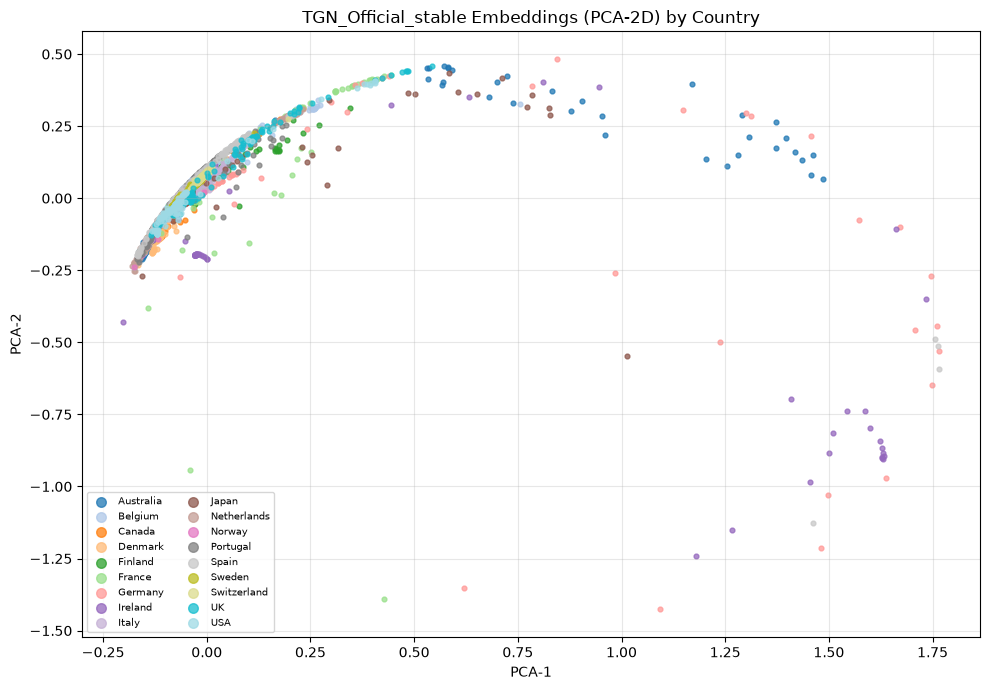

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase7\figures\tgn_official_pca_by_country.png

Final embeddings promoted for next phases:
  emb_TGN_Official.npy : (2718, 64)
  emb_TGN_GAT.npy      : (2718, 32)

Cell 8 completed successfully.


In [2]:
# Phase 7 – Graph Representation Learning
# Cell 8 (Fixed): Embedding Quality Evaluation + Final Selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase7" / "figures"

print("=" * 60)
print("Phase 7 | Cell 8 (Fixed): Embedding Quality Evaluation")
print("=" * 60)

# Load stable TGN embeddings
emb_off = np.load(OUT_DATA / "emb_TGN_Official_stable.npy")
emb_gat = np.load(OUT_DATA / "emb_TGN_GAT_stable.npy")
meta = pd.read_csv(OUT_TAB / "embedding_meta_stable.csv")

# Also load earlier GNN embeddings if available
emb_files = {
    "TGN_Official_stable": emb_off,
    "TGN_GAT_stable": emb_gat,
}
for name in ["GCN", "GraphSAGE", "GAT"]:
    path = OUT_DATA / f"emb_{name}_graph_norm.npy"
    if path.exists():
        emb_files[name] = np.load(path)

# ---------------------- Quality metrics ----------------------
rows = []
rng = np.random.RandomState(42)

for name, emb in emb_files.items():
    emb = np.nan_to_num(emb, nan=0.0, posinf=0.0, neginf=0.0)
    
    mean_abs = np.mean(np.abs(emb))
    std = np.std(emb)
    rank = np.linalg.matrix_rank(emb)
    
    n_comp = min(5, emb.shape[1], emb.shape[0] - 1)
    pca = PCA(n_components=n_comp)
    pca.fit(emb)
    var_explained = float(pca.explained_variance_ratio_.sum())
    
    try:
        labels = meta["country"].values
        idx = rng.choice(len(emb), size=min(800, len(emb)), replace=False)
        sil = float(silhouette_score(emb[idx], labels[idx]))
    except Exception:
        sil = np.nan
    
    rows.append({
        "model": name,
        "dim": emb.shape[1],
        "mean_abs": round(mean_abs, 4),
        "std": round(std, 4),
        "rank": int(rank),
        "pca_var_top5": round(var_explained, 4),
        "silhouette_country": round(sil, 4) if not np.isnan(sil) else np.nan
    })

quality_df = pd.DataFrame(rows).sort_values("silhouette_country", ascending=False)
print("\n--- Embedding Quality Summary ---")
print(quality_df.to_string(index=False))
quality_df.to_csv(OUT_TAB / "embedding_quality_benchmark.csv", index=False)

# ---------------------- PCA visualization for TGN_Official ----------------------
pca2 = PCA(n_components=2)
emb2 = pca2.fit_transform(emb_off)

plt.figure(figsize=(10, 7))
countries = sorted(meta["country"].unique())

# Compatible colormap for new matplotlib
try:
    cmap = plt.colormaps.get_cmap("tab20").resampled(len(countries))
except Exception:
    cmap = plt.cm.tab20

for i, c in enumerate(countries):
    mask = meta["country"].values == c
    color = cmap(i / max(len(countries) - 1, 1)) if hasattr(cmap, "__call__") else cmap(i)
    plt.scatter(emb2[mask, 0], emb2[mask, 1], s=12, alpha=0.75, label=c, color=color)

plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("TGN_Official_stable Embeddings (PCA-2D) by Country")
plt.legend(markerscale=2, fontsize=7, ncol=2, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG / "tgn_official_pca_by_country.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'tgn_official_pca_by_country.png'}")

# ---------------------- Promote stable embeddings as final for RL ----------------------
np.save(OUT_DATA / "emb_TGN_Official.npy", emb_off)
np.save(OUT_DATA / "emb_TGN_GAT.npy", emb_gat)

print("\nFinal embeddings promoted for next phases:")
print(f"  emb_TGN_Official.npy : {emb_off.shape}")
print(f"  emb_TGN_GAT.npy      : {emb_gat.shape}")

print("\nCell 8 completed successfully.")

In [3]:
# Phase 7 – Graph Representation Learning
# Cell 9: Finalize Artifacts for RL Phases

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase7" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase7" / "tables"
PHASE6_DATA = PROJECT / "outputs" / "phase6" / "data"

print("=" * 60)
print("Phase 7 | Cell 9: Finalize Artifacts for Next Phases")
print("=" * 60)

# Load final stable embeddings (already promoted in Cell 8)
emb_off = np.load(OUT_DATA / "emb_TGN_Official.npy")
emb_gat = np.load(OUT_DATA / "emb_TGN_GAT.npy")
meta = pd.read_csv(OUT_TAB / "embedding_meta_stable.csv")

# Feature matrix with SR
fm = pd.read_pickle(PHASE6_DATA / "feature_matrix_with_sr.pkl")

# Align order: merge on country-year to guarantee same ordering
fm_aligned = pd.merge(meta, fm, on=["country", "year"], how="left")

# base_features = numeric columns except country/year
drop_cols = ["country", "year"]
base_cols = [c for c in fm_aligned.columns if c not in drop_cols]
base_features = (
    fm_aligned[base_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
    .astype(np.float32)
    .values
)

np.save(OUT_DATA / "base_features.npy", base_features)

# node_list for compatibility with later phases
node_list = meta[["country"]].copy()
node_list.to_csv(OUT_DATA / "node_list.csv", index=False)

# Save aligned merged matrix
fm_aligned.to_pickle(OUT_DATA / "feature_matrix_with_embeddings_final.pkl")
fm_aligned.to_csv(OUT_TAB / "feature_matrix_with_embeddings_final.csv", index=False)

print("Final artifacts:")
print(f"  base_features.npy              : {base_features.shape}")
print(f"  emb_TGN_Official.npy           : {emb_off.shape}")
print(f"  emb_TGN_GAT.npy                : {emb_gat.shape}")
print(f"  node_list.csv                  : {len(node_list)} rows")
print(f"  feature_matrix_with_embeddings_final.pkl : {fm_aligned.shape}")

# Sanity checks
assert base_features.shape[0] == emb_off.shape[0] == emb_gat.shape[0] == len(meta)
print("\nAlignment check: PASSED")
print("\nCell 9 completed successfully.")

Phase 7 | Cell 9: Finalize Artifacts for Next Phases
Final artifacts:
  base_features.npy              : (2718, 48)
  emb_TGN_Official.npy           : (2718, 64)
  emb_TGN_GAT.npy                : (2718, 32)
  node_list.csv                  : 2718 rows
  feature_matrix_with_embeddings_final.pkl : (2718, 50)

Alignment check: PASSED

Cell 9 completed successfully.
